In [13]:
# %matplotlib inline
# %matplotlib notebook
%matplotlib widget


# Fuzzy C-Means

Hi class, lets explore the vallina fuzzy c-means

First, lets read in the IRIS data set.

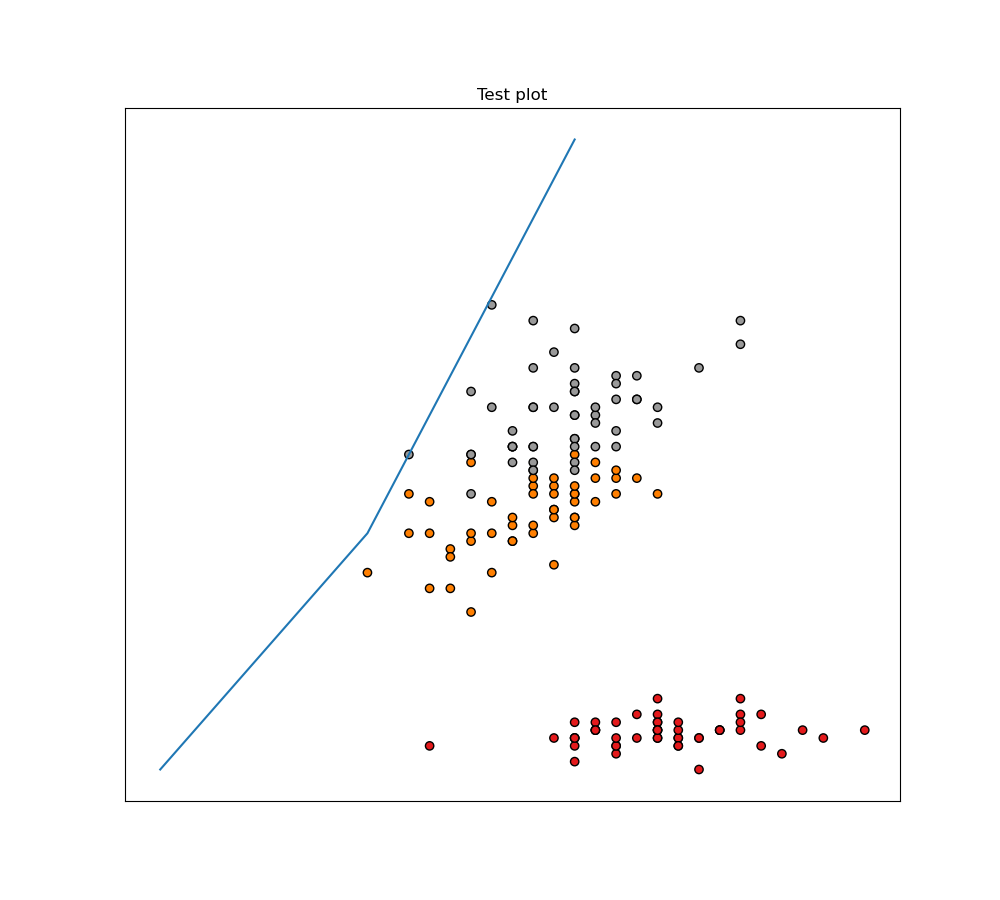

In [14]:
# %matplotlib inline
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [1, 4, 9])
plt.title("Test plot")
plt.show()

Shape of iris: (150, 4)


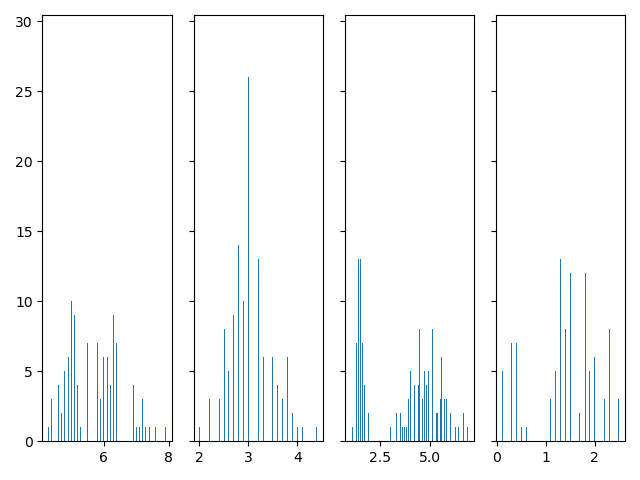

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
import numpy as np

# import some data to play with
iris = datasets.load_iris()
print( "Shape of iris:", np.shape(iris.data) )
sampleCount = iris.data.shape[0]
featureCount = iris.data.shape[1]

# lets plot all the individual features
fig, axs = plt.subplots(1, 4, sharey=True, tight_layout=True)  # 1 row 4 cols, all histograms share the same y-axis
# axs = [axs[0], axs[1], axs[2], axs[3]] since we asked for 1 row and 4 columns.

for i in range(4):
    X = iris.data[:,i] # extract one of the features each iteration.
    x_min, x_max = X[:].min() - .5, X[:].max() + .5
    axs[i].hist(X, bins=sampleCount)

Now, plot all the tuples

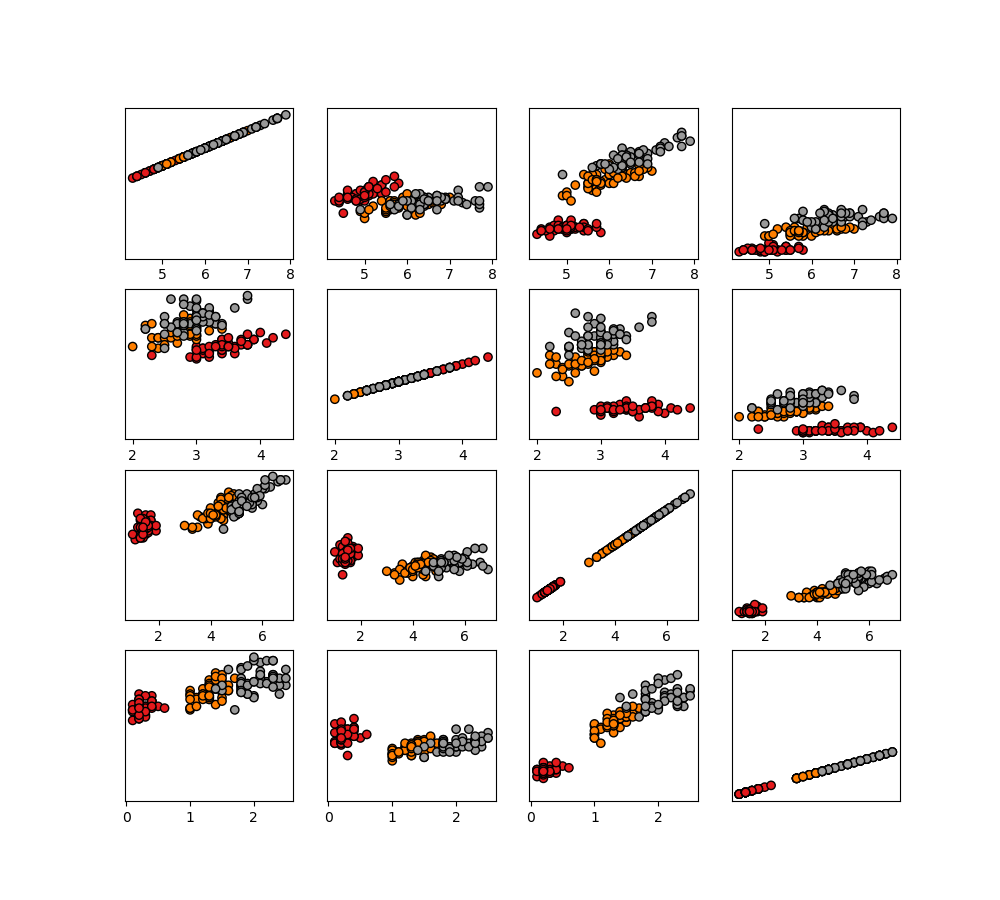

In [16]:
fig, axs = plt.subplots(4, 4, sharey=True, figsize=(10, 9))

# This is called scatterplot matrix.
# The nested loop iterate over each combinaiton of features, we can observe:
# which features separate class well;
# correlations between features 
# clustering behaviors

# The diagonal is pointless.... feature i vs feature i
# The figure is diagonal:
#         F1      F2      F3      F4
# F1    (1,1)   (1,2)   (1,3)   (1,4)
# F2    (2,1)   (2,2)   (2,3)   (2,4)
# F3    (3,1)   (3,2)   (3,3)   (3,4)
# F4    (4,1)   (4,2)   (4,3)   (4,4)


for i in range(4):
    for j in range(4):
        X1 = iris.data[:,i]
        X2 = iris.data[:,j]
        y = iris.target  
        axs[i,j].scatter(X1, X2, c=y, cmap=plt.cm.Set1, edgecolor='k') # For each subplot, use X1 as x-coordinate, use X2 as y coordinatte. color each point according to y(label)
        # remark: cmap=plt.cm.Set1 is a categorical colormap with strong distinct colors    edgecolor='k' — black outline around points
        plt.xticks(())
        plt.yticks(())
plt.show()

In [17]:
# %matplotlib widget
# import matplotlib.pyplot as 
import matplotlib
print(matplotlib.get_backend())

module://ipympl.backend_nbagg


Now, the tripples

In [18]:
# # (1,2,3)
# fig = plt.figure(figsize=(6, 6))
# ax = Axes3D(fig, elev=-150, azim=110)
# ax.scatter(iris.data[:,0], iris.data[:,1], iris.data[:,2], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)  
# plt.show()
# # (1,2,4)
# fig = plt.figure(figsize=(6, 6))
# ax = Axes3D(fig, elev=-150, azim=110)
# ax.scatter(iris.data[:,0], iris.data[:,1], iris.data[:,3], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)
# plt.show()
# # (2,3,4)
# fig = plt.figure(figsize=(6, 6))
# ax = Axes3D(fig, elev=-150, azim=110)
# ax.scatter(iris.data[:,1], iris.data[:,2], iris.data[:,3], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)
# plt.show()

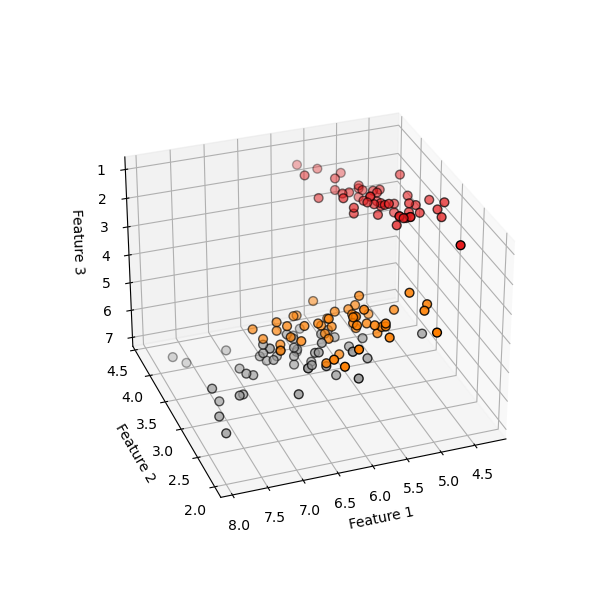

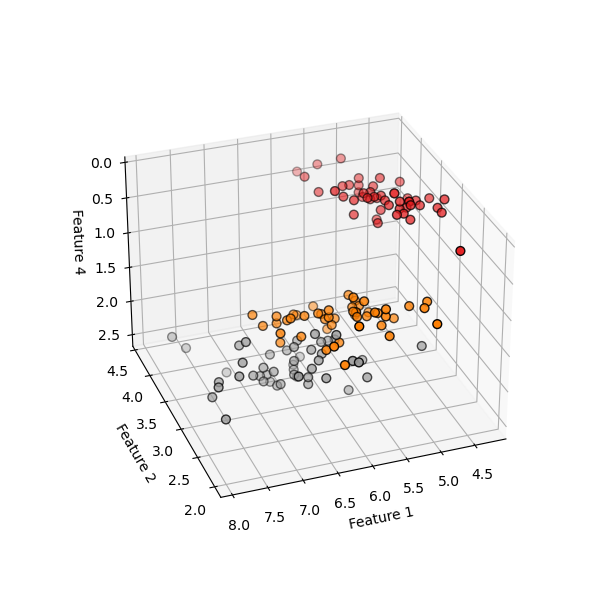

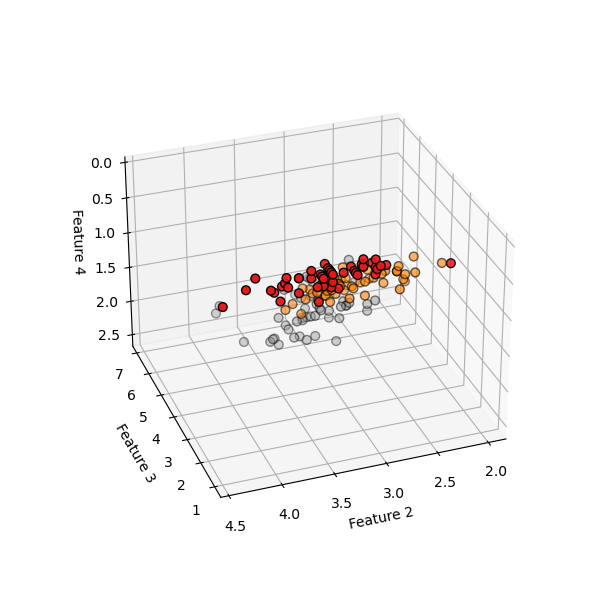

In [19]:
%matplotlib widget

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # 其实现在可写可不写
from sklearn.datasets import load_iris

# 载入数据
iris = load_iris()
X = iris.data
y = iris.target

# (1,2,3)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=-150, azim=110)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40) # c=y means the color = y values(labels)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.show()

# (1,2,4)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=-150, azim=110)
ax.scatter(X[:, 0], X[:, 1], X[:, 3], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 4")
plt.show()

# (2,3,4)
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=-150, azim=110)
ax.scatter(X[:, 1], X[:, 2], X[:, 3], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)
ax.set_xlabel("Feature 2")
ax.set_ylabel("Feature 3")
ax.set_zlabel("Feature 4")
plt.show()


Now, run the simple version of the FCM

In [20]:
from sklearn.metrics.pairwise import euclidean_distances
from IPython import display

X = iris.data  

# lets pick prototype's from the data randomly
C = 3
Prototypes = np.zeros((C,featureCount))
for i in range(C):
    WhichSample = np.random.randint(0, sampleCount)
    Prototypes[i,:] = X[WhichSample,:]
print( "Prototypes start" )
print( Prototypes )

# this is our membership matrix
MembMatrix = np.zeros((sampleCount,C))

# fuzzy factor
M = 1.5

# run that algorithm
T = 300
for t in range(T):
    
    # get pair wise distances
    X_P_DistMatrix = euclidean_distances(Prototypes,X)

    # update memb matrix
    for i in range(C):
        for n in range(sampleCount):
            sumv = 0
            top = X_P_DistMatrix[i,n]
            for m in range(C):                
                bottom = X_P_DistMatrix[m,n]
                sumv = sumv + pow(top / (bottom + np.finfo(float).eps),1.0/(M-1.0))
            MembMatrix[n,i] = min(max(1.0 / (sumv + np.finfo(float).eps),0.0),1.0)            
    
    # update protos
    for c in range(C):
        Top = np.zeros((1,featureCount))
        Bottom = 0        
        for n in range(sampleCount):
            Top = Top + ( X[n,:] * pow(MembMatrix[n,c],M) )
            Bottom = Bottom + pow(MembMatrix[n,c],M)
        Prototypes[c,:] = Top / (Bottom + np.finfo(float).eps)
    
print( "Prototypes end" )
print( Prototypes )

Prototypes start
[[4.7 3.2 1.3 0.2]
 [6.5 2.8 4.6 1.5]
 [5.  3.5 1.6 0.6]]
Prototypes end
[[5.01518232 3.40243746 1.52235322 0.27010835]
 [6.69424737 3.02489381 5.53225743 1.99917729]
 [5.92148046 2.77270738 4.40005835 1.41578855]]


Plot it (well, in a few dims)

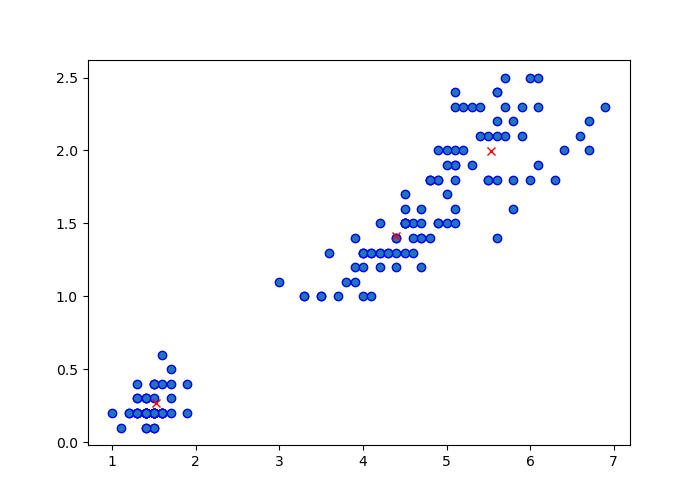

In [21]:
import pylab as pl

Dim1 = 2
X1 = iris.data[:,Dim1]
X2 = iris.data[:,Dim1+1]
fig, ax = pl.subplots(nrows = 1, ncols = 1, figsize=(7, 5))
pl.scatter(X1, X2, edgecolor='b')  
pl.plot(Prototypes[:,Dim1],Prototypes[:,Dim1+1],'xr')
pl.show()

Show the membership matrix as an "image"

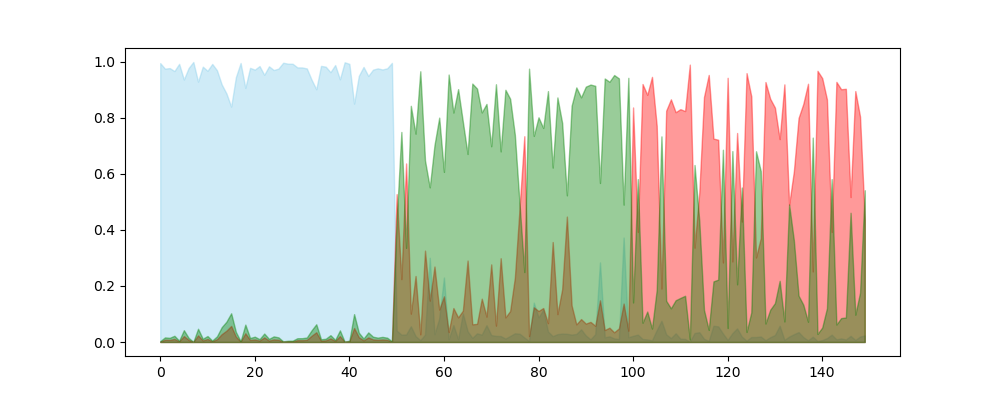

In [22]:
colors = ["skyblue","red","green"]

plt.figure( figsize=(10, 4) )

for i in range(C):
    b=range(0,sampleCount)
    plt.fill_between( b, MembMatrix[:,i], color=colors[i], alpha=0.4)
plt.show()

Harden the matrix

In [23]:
Harden = np.argmax( MembMatrix, axis=1 )
print(Harden)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 1 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1 1 1
 1 2]


Show the results

/var/folders/fl/vvv7fdkj2139zp4my83vm89r0000gn/T/ipykernel_58702/540298159.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure( figsize=(10, 9) )


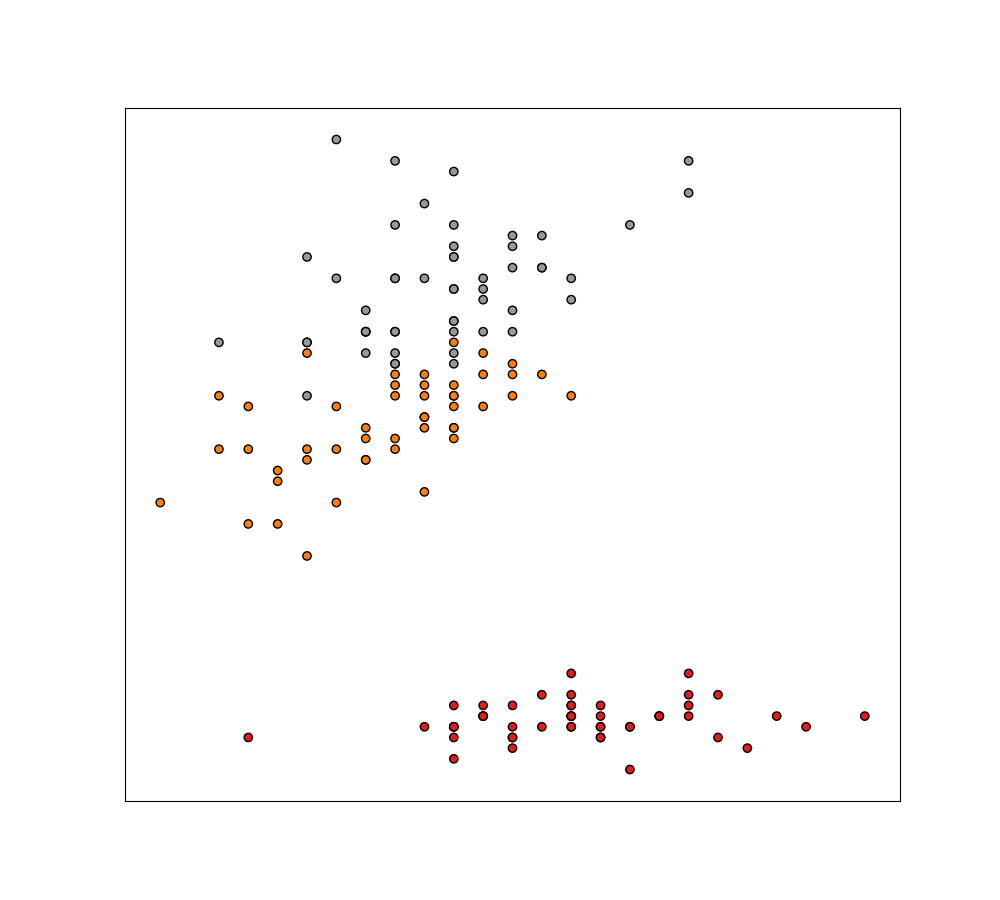

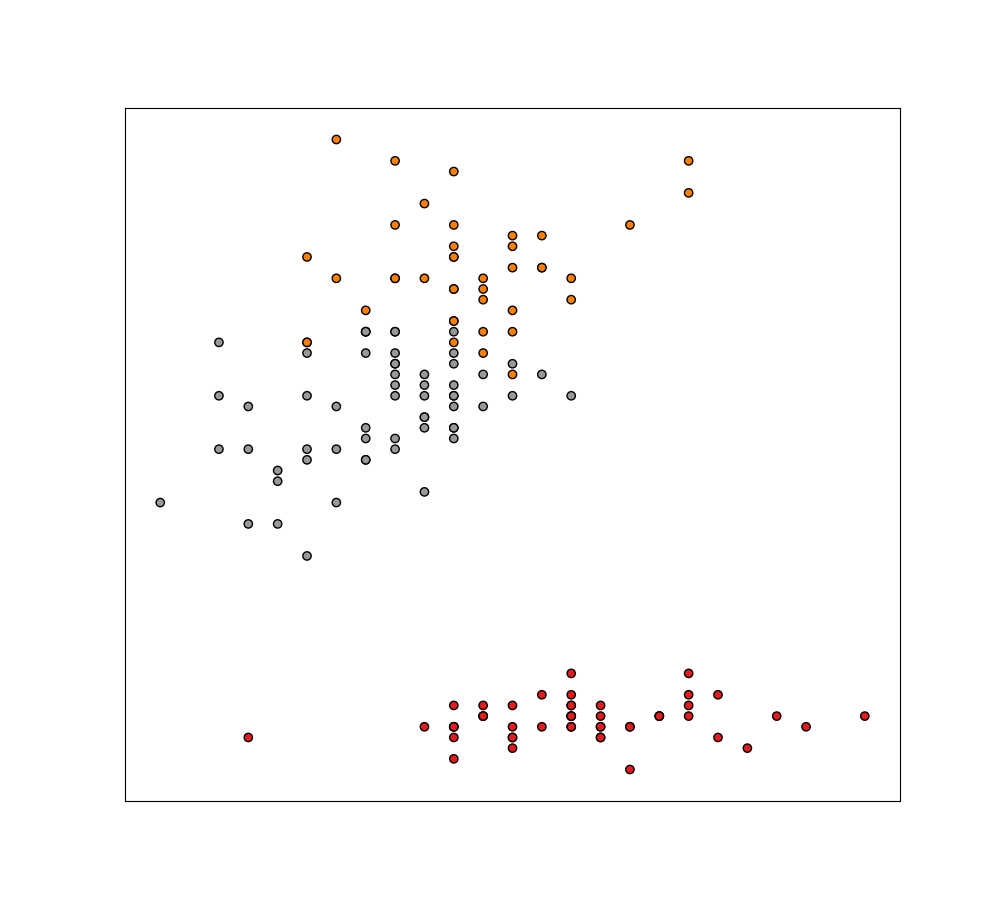

In [24]:
# what we got
plt.figure( figsize=(10, 9) )
i = 1
j = 2
X1 = iris.data[:,i]
X2 = iris.data[:,j]
y = Harden
plt.scatter(X1, X2, c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xticks(())
plt.yticks(())

# real results
plt.figure( figsize=(10, 9) )
i = 1
j = 2
X1 = iris.data[:,i]
X2 = iris.data[:,j]
y = iris.target
plt.scatter(X1, X2, c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xticks(())
plt.yticks(())

plt.show()